In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [31]:
D1 = pd.read_csv('/content/diabetes_dataset.csv')

In [32]:
D1.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [33]:
D1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [34]:
D1.isnull().sum()

,0
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


In [35]:
D1.duplicated().sum()

np.int64(14)

In [36]:
D1 = D1.drop_duplicates()

In [37]:
D1

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0


In [38]:
if 'gender' in D1.columns:
    D1 = pd.get_dummies(D1, columns=['gender'])

In [39]:
le = LabelEncoder()

for col in ['location', 'smoking_history']:
    if col in D1.columns:
        D1[col] = le.fit_transform(D1[col].astype(str))

In [40]:
D1

,year,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other
0,2020,32.0,0,0,0,0,0,1,0,0,4,27.32,5.0,100,0,True,False,False
1,2015,29.0,0,0,1,0,0,0,0,0,4,19.95,5.0,90,0,True,False,False
2,2015,18.0,0,0,0,0,0,1,0,0,4,23.76,4.8,160,0,False,True,False
3,2015,41.0,0,0,0,1,0,0,0,0,4,27.32,4.0,159,0,False,True,False
4,2016,52.0,0,1,0,0,0,0,0,0,4,23.75,6.5,90,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,33.0,54,0,0,0,0,1,0,0,4,21.21,6.5,90,0,True,False,False
99996,2016,80.0,54,0,1,0,0,0,0,0,0,36.66,5.7,100,0,True,False,False
99997,2018,46.0,54,0,1,0,0,0,0,0,2,36.12,6.2,158,0,False,True,False
99998,2018,51.0,54,1,0,0,0,0,0,0,5,29.29,6.0,155,0,True,False,False


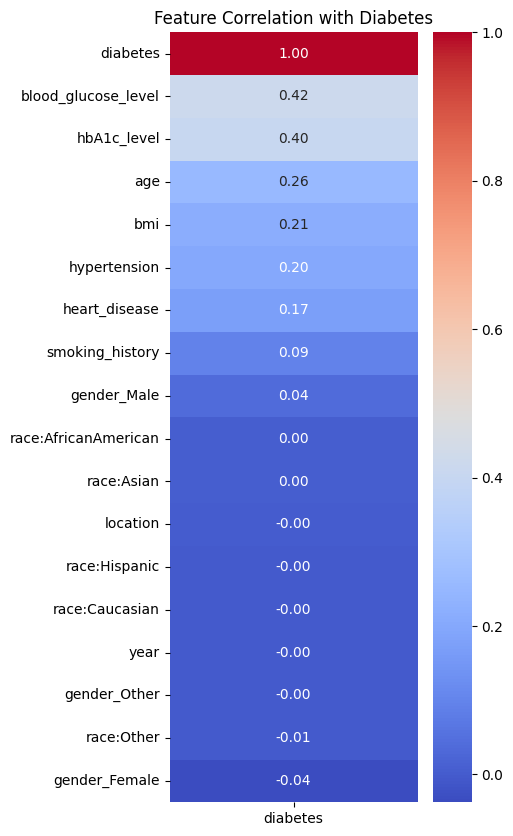

In [46]:
plt.figure(figsize=(4, 10))
# Calculating correlation specifically for the 'diabetes' column
diabetes_corr = D1.corr()[['diabetes']].sort_values(by='diabetes', ascending=False)

# Creating the vertical heatmap
sns.heatmap(diabetes_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Diabetes')
plt.show()

In [48]:
# Calculate correlation with target
corr_matrix = D1.corr()
diabetes_corr = corr_matrix['diabetes']

# Identify features with correlation between -0.1 and 0.1
features_to_drop = diabetes_corr[abs(diabetes_corr) < 0.1].index.tolist()

# Drop the identified features
D1 = D1.drop(columns=features_to_drop)

print(f"Dropped features: {features_to_drop}")
print(f"Remaining columns: {D1.columns.tolist()}")
D1.head()

Dropped features: []
Remaining columns: ['age', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']


,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
0,32.0,0,0,27.32,5.0,100,0
1,29.0,0,0,19.95,5.0,90,0
2,18.0,0,0,23.76,4.8,160,0
3,41.0,0,0,27.32,4.0,159,0
4,52.0,0,0,23.75,6.5,90,0


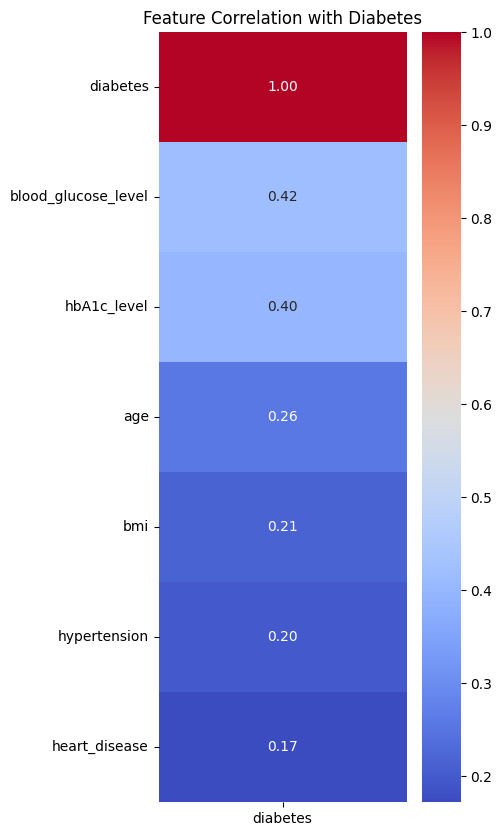

In [49]:
plt.figure(figsize=(4, 10))
# Calculating correlation specifically for the 'diabetes' column
diabetes_corr = D1.corr()[['diabetes']].sort_values(by='diabetes', ascending=False)

# Creating the vertical heatmap
sns.heatmap(diabetes_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Diabetes')
plt.show()

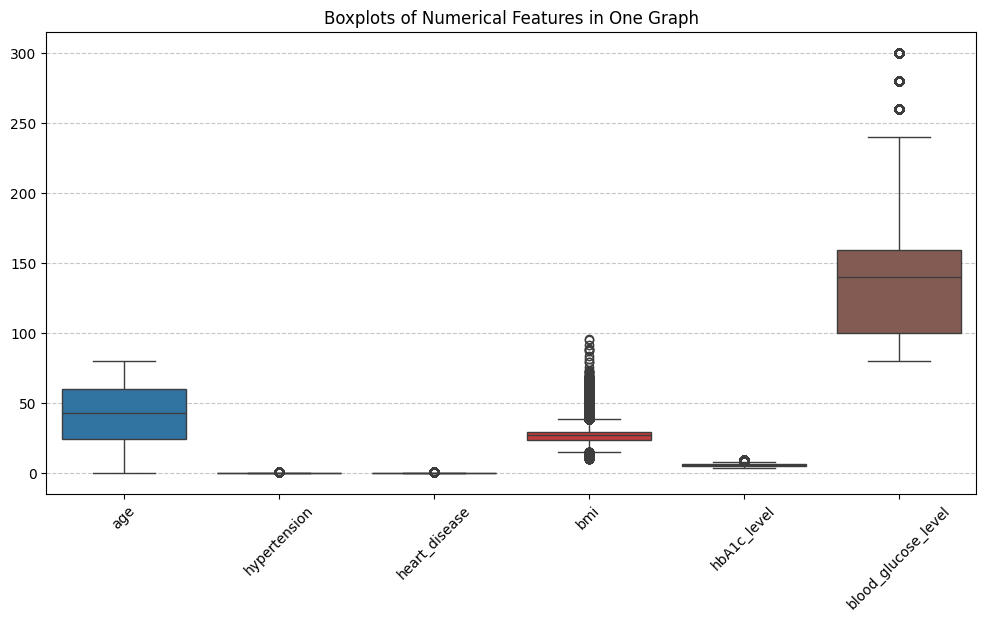

In [53]:
# Visualizing all features in one single plot for direct comparison
plt.figure(figsize=(12, 6))
sns.boxplot(data=D1.drop(columns=['diabetes']))
plt.xticks(rotation=45)
plt.title("Boxplots of Numerical Features in One Graph")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [59]:
# Identify numerical features (excluding target)
features_to_clean = [col for col in D1.columns if col != 'diabetes']

# Calculate Q1, Q3, and IQR
Q1 = D1[features_to_clean].quantile(0.25)
Q3 = D1[features_to_clean].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter D1 to remove outliers across all features and create DC
DC = D1[~((D1[features_to_clean] < lower_bound) | (D1[features_to_clean] > upper_bound)).any(axis=1)].copy()


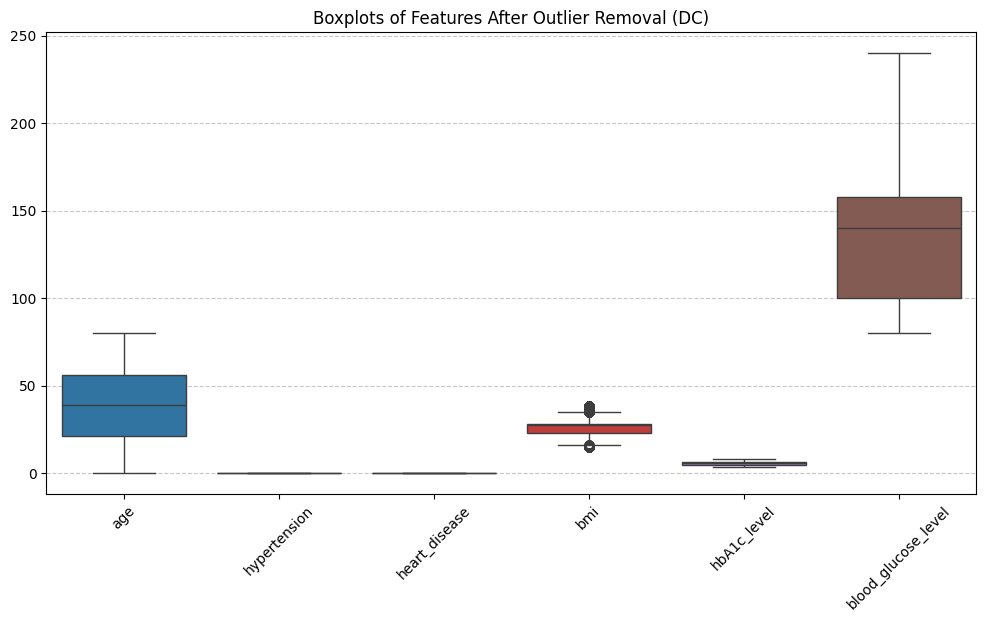

In [57]:
# Visualizing the cleaned data DC
plt.figure(figsize=(12, 6))
sns.boxplot(data=DC.drop(columns=['diabetes']))
plt.xticks(rotation=45)
plt.title("Boxplots of Features After Outlier Removal (DC)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [60]:
DC

,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
0,32.0,0,0,27.32,5.0,100,0
1,29.0,0,0,19.95,5.0,90,0
2,18.0,0,0,23.76,4.8,160,0
3,41.0,0,0,27.32,4.0,159,0
4,52.0,0,0,23.75,6.5,90,0
...,...,...,...,...,...,...,...
99995,33.0,0,0,21.21,6.5,90,0
99996,80.0,0,0,36.66,5.7,100,0
99997,46.0,0,0,36.12,6.2,158,0
99998,51.0,0,0,29.29,6.0,155,0


In [63]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Define the columns to scale
cols_to_scale = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level']

# Apply scaling to the DC DataFrame
DC[cols_to_scale] = scaler.fit_transform(DC[cols_to_scale])

In [64]:
DC

,age,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
0,0.399399,0,0,0.530055,0.319149,0.12500,0
1,0.361862,0,0,0.220261,0.319149,0.06250,0
2,0.224224,0,0,0.380412,0.276596,0.50000,0
3,0.512012,0,0,0.530055,0.106383,0.49375,0
4,0.649650,0,0,0.379992,0.638298,0.06250,0
...,...,...,...,...,...,...,...
99995,0.411912,0,0,0.273224,0.638298,0.06250,0
99996,1.000000,0,0,0.922657,0.468085,0.12500,0
99997,0.574575,0,0,0.899958,0.574468,0.48750,0
99998,0.637137,0,0,0.612863,0.531915,0.46875,0


In [66]:
# Define features (X) and target (y)
X = DC.drop(columns=['diabetes'])
y = DC['diabetes']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (65550, 6)
Testing set shape: (16388, 6)


LR

Model Accuracy: 0.9713

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     15803
           1       0.81      0.25      0.39       585

    accuracy                           0.97     16388
   macro avg       0.89      0.63      0.69     16388
weighted avg       0.97      0.97      0.96     16388



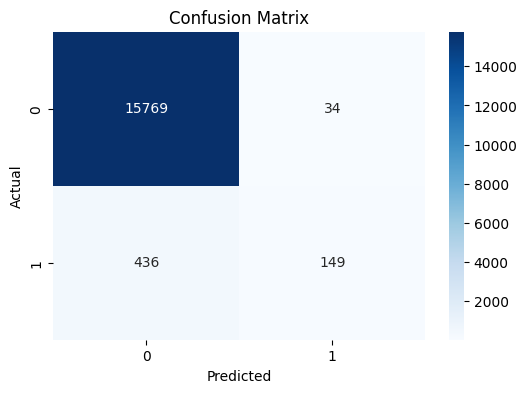

In [75]:
# Initialize and train the Logistic Regression model with 10000 iterations
model = LogisticRegression(random_state=42, max_iter=100000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

SVM

SVM Model Accuracy: 0.9743

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     15803
           1       1.00      0.28      0.44       585

    accuracy                           0.97     16388
   macro avg       0.99      0.64      0.71     16388
weighted avg       0.97      0.97      0.97     16388



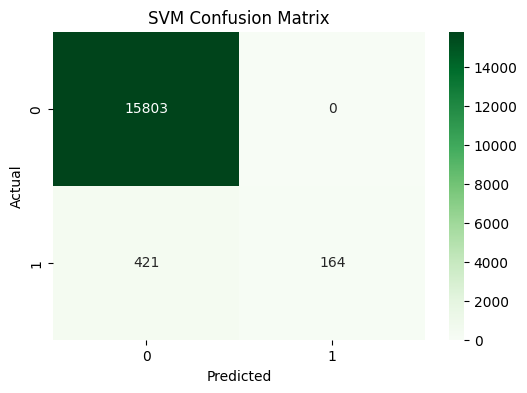

In [76]:
from sklearn.svm import SVC

# Initialize and train the SVM model with a specified max_iter
# Note: default is -1 (no limit), setting to 10000 as requested
svm_model = SVC(kernel='rbf', random_state=42, max_iter=100000)
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"SVM Model Accuracy: {svm_accuracy:.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

# Display Confusion Matrix for SVM
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

NB

Naive Bayes Model Accuracy: 0.9683

Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     15803
           1       0.67      0.22      0.33       585

    accuracy                           0.97     16388
   macro avg       0.82      0.61      0.66     16388
weighted avg       0.96      0.97      0.96     16388



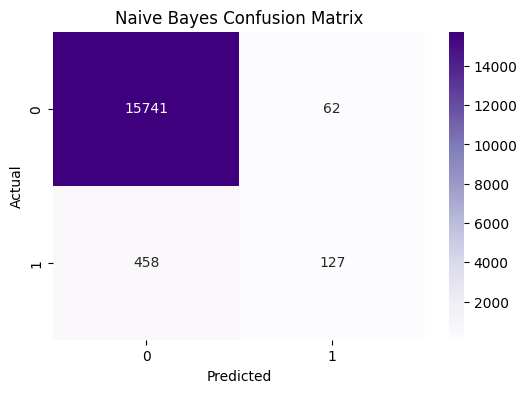

In [74]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train the Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Model Accuracy: {nb_accuracy:.4f}")
print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Display Confusion Matrix for Naive Bayes
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

DT

Decision Tree Model Accuracy: 0.9669

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     15803
           1       0.54      0.51      0.53       585

    accuracy                           0.97     16388
   macro avg       0.76      0.75      0.75     16388
weighted avg       0.97      0.97      0.97     16388



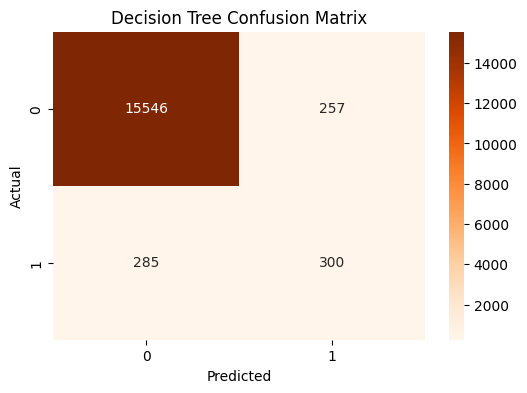

In [78]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Model Accuracy: {dt_accuracy:.4f}")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Display Confusion Matrix for Decision Tree
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

KNN

The best K value found is: 6


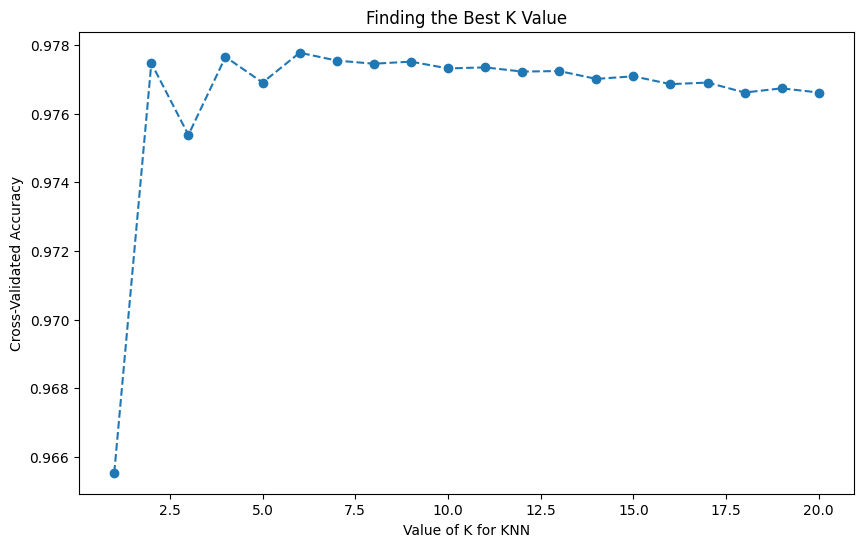

KNN Model Accuracy with K=6: 0.9763

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15803
           1       0.97      0.35      0.51       585

    accuracy                           0.98     16388
   macro avg       0.97      0.67      0.75     16388
weighted avg       0.98      0.98      0.97     16388



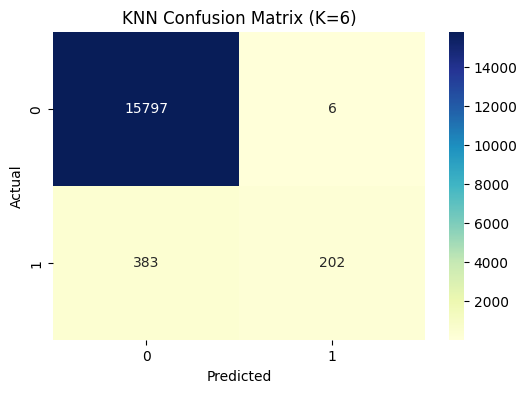

In [79]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Finding the best K value using cross-validation on a subset for speed
k_range = range(1, 21)
k_scores = []

# We use a smaller sample for the search if the dataset is large to save time
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# Get the best K
best_k = k_range[np.argmax(k_scores)]
print(f"The best K value found is: {best_k}")

# Plotting the K values vs Accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o', linestyle='dashed')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Finding the Best K Value')
plt.show()

# Training KNN with the best K
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred_knn = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"KNN Model Accuracy with K={best_k}: {knn_accuracy:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.show()

RF

Random Forest Model Accuracy: 0.9775

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15803
           1       0.85      0.45      0.59       585

    accuracy                           0.98     16388
   macro avg       0.91      0.72      0.79     16388
weighted avg       0.98      0.98      0.97     16388



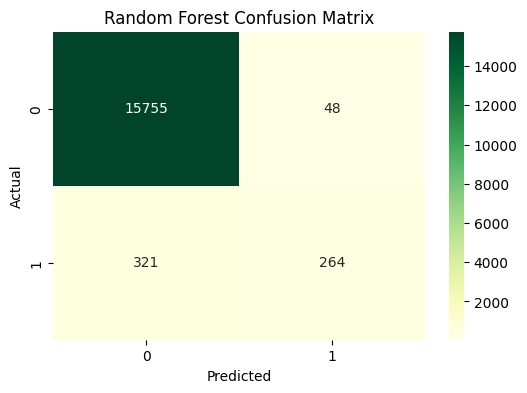

In [82]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Model Accuracy: {rf_accuracy:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Display Confusion Matrix for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='YlGn')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

XGboost

XGBoost Model Accuracy: 0.9796

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15803
           1       0.97      0.44      0.61       585

    accuracy                           0.98     16388
   macro avg       0.98      0.72      0.80     16388
weighted avg       0.98      0.98      0.98     16388



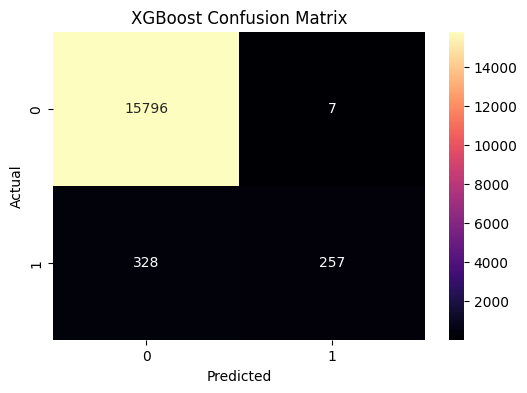

In [88]:
from xgboost import XGBClassifier

# Initialize and train the XGBoost model
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Model Accuracy: {xgb_accuracy:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# Display Confusion Matrix for XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()

bagging

Bagging Model Accuracy: 0.9773

Bagging Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15803
           1       0.83      0.46      0.59       585

    accuracy                           0.98     16388
   macro avg       0.90      0.73      0.79     16388
weighted avg       0.97      0.98      0.97     16388



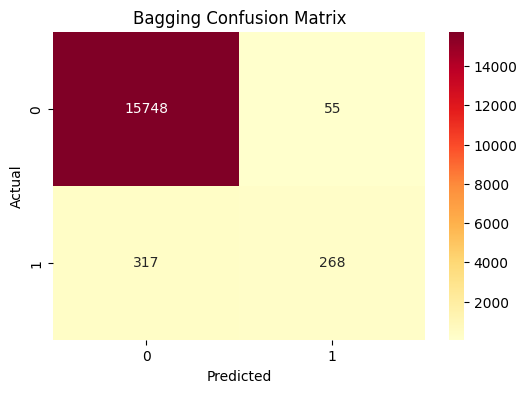

In [89]:
from sklearn.ensemble import BaggingClassifier

# Initialize and train the Bagging model (using Decision Trees by default)
bagging_model = BaggingClassifier(n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_bagging = bagging_model.predict(X_test)

# Evaluate the model
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
print(f"Bagging Model Accuracy: {bagging_accuracy:.4f}")
print("\nBagging Classification Report:")
print(classification_report(y_test, y_pred_bagging))

# Display Confusion Matrix for Bagging
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_bagging), annot=True, fmt='d', cmap='YlOrRd')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Bagging Confusion Matrix')
plt.show()

Gboost

Gradient Boosting Model Accuracy: 0.9799

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     15803
           1       1.00      0.44      0.61       585

    accuracy                           0.98     16388
   macro avg       0.99      0.72      0.80     16388
weighted avg       0.98      0.98      0.98     16388



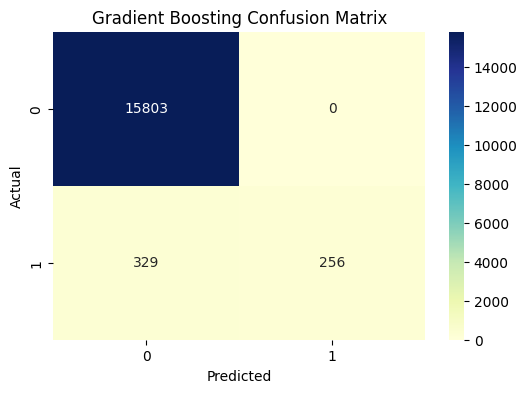

In [100]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.01, max_depth=7, random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
gb_accuracy = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Model Accuracy: {gb_accuracy:.4f}")
print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

# Display Confusion Matrix for Gradient Boosting
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Gradient Boosting Confusion Matrix')
plt.show()